# ILDC-CJPE: Legal Judgment Prediction
## Latent Discourse Trajectory Modeling with BiGRU

**Pipeline:**
1. Load train/dev/test parquet files
2. Drop all-null expert columns
3. Extract sentence embeddings via Sentence-BERT
4. Build global latent discourse vocabulary using MiniBatchKMeans
5. Convert documents to discourse trajectories
6. Train DiscourseBiGRU classifier
7. Ablation studies + full evaluation

## Cell 1 — Install Dependencies

In [1]:
%%capture
!pip install sentence-transformers scikit-learn pandas pyarrow torch torchvision torchaudio seaborn matplotlib

## Cell 2 — Imports

In [2]:
import os, re, pickle, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sentence_transformers import SentenceTransformer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score,
    f1_score, roc_auc_score,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Cell 3 — Configuration

In [21]:
# ── Paths ──────────────────────────────────────────────────────────────────
TRAIN_PATH = '/kaggle/input/datasets/joyal9777/ildc-dataset-cjpe/ILDC_dataset/cjpe/single_train-00000-of-00001.parquet'
DEV_PATH   = '/kaggle/input/datasets/joyal9777/ildc-dataset-cjpe/ILDC_dataset/cjpe/single_dev-00000-of-00001.parquet'
TEST_PATH  = '/kaggle/input/datasets/joyal9777/ildc-dataset-cjpe/ILDC_dataset/cjpe/test-00000-of-00001.parquet'

CACHE_DIR  = '/kaggle/working'

# ── Model / Training ───────────────────────────────────────────────────────
SBERT_MODEL  = 'sentence-transformers/all-mpnet-base-v2'
EMBED_DIM    = 768        # Sentence-BERT output dim
N_CLUSTERS   = 12          # Latent discourse states
STATE_DIM    = 64         # Discourse state embedding dim
MAX_LEN      = 64         # Max sentences per document
COMBINED_DIM = EMBED_DIM + STATE_DIM  # 832

HIDDEN_SIZE  = 256
BATCH_SIZE   = 16
NUM_EPOCHS   = 20
LR           = 2e-4
WEIGHT_DECAY = 1e-4
MAX_NORM     = 1.0
DROPOUT      = 0.3

BEST_MODEL_PATH  = 'best_discourse_bigru.pt'
FINAL_MODEL_PATH = 'discourse_bigru_final.pt'
KMEANS_PATH      = 'global_discourse_kmeans.pkl'

EXPERT_COLS = ['expert_1','expert_2','expert_3','expert_4','expert_5']

print('Config ready.')
print(f'COMBINED_DIM = {COMBINED_DIM}')

Config ready.
COMBINED_DIM = 832


## Cell 4 — Data Loading & Inspection

In [22]:
# Load parquet files
train_df = pd.read_parquet(TRAIN_PATH)
dev_df   = pd.read_parquet(DEV_PATH)
test_df  = pd.read_parquet(TEST_PATH)

# Drop all-null expert columns
for df in [train_df, dev_df, test_df]:
    cols_to_drop = [c for c in EXPERT_COLS if c in df.columns]
    df.drop(columns=cols_to_drop, inplace=True)

print('=== train_df ===')
train_df.info()
print('\n=== dev_df ===')
dev_df.info()
print('\n=== test_df ===')
test_df.info()

print('\n--- Class Distributions ---')
print('Train:')
print(train_df['label'].value_counts())
print('\nDev:')
print(dev_df['label'].value_counts())
print('\nTest:')
print(test_df['label'].value_counts())

=== train_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5082 entries, 0 to 5081
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      5082 non-null   object
 1   text    5082 non-null   object
 2   label   5082 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 119.2+ KB

=== dev_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2511 entries, 0 to 2510
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2511 non-null   object
 1   text    2511 non-null   object
 2   label   2511 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 59.0+ KB

=== test_df ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1517 entries, 0 to 1516
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      1517 non-null   object
 1   text    1517 non-null   object
 2   label   1517 non-nul

## Cell 5 — Sentence Splitting Utility

In [23]:
def split_sentences(text: str) -> list[str]:
    """Split document text into sentences using regex."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ['']
    # Split on sentence-ending punctuation followed by whitespace
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())
    # Filter out very short fragments
    sentences = [s.strip() for s in sentences if len(s.strip()) > 5]
    return sentences if sentences else [text.strip()]

# Quick sanity check
sample = train_df['text'].iloc[0]
sents  = split_sentences(sample)
print(f'Sample document → {len(sents)} sentences')
print('First 3 sentences:')
for s in sents[:3]:
    print(' •', s[:120])

Sample document → 207 sentences
First 3 sentences:
 • NARIMAN, J.
 • Leave granted.
 • In 2008, the Punjab State Water Supply Sewerage Board, Bhatinda issued numberice inviting tender for extension and augme


## Cell 6 — Sentence Embedding Generation (with caching)

In [24]:
import numpy as np

train_embs = np.load(
    "/kaggle/input/datasets/joyal9777/embeddings/cache_train_embs.npy",
    allow_pickle=True
).tolist()

dev_embs = np.load(
    "/kaggle/input/datasets/joyal9777/embeddings/cache_dev_embs.npy",
    allow_pickle=True
).tolist()

test_embs = np.load(
    "/kaggle/input/datasets/joyal9777/embeddings/cache_test_embs.npy",
    allow_pickle=True
).tolist()

In [8]:
print(type(train_embs))
print(len(train_embs))
print(type(train_embs[0]))
print(train_embs[0].shape)

<class 'list'>
5082
<class 'numpy.ndarray'>
(64, 768)


In [9]:
all_train_sents = np.vstack(train_embs)

print(all_train_sents.shape)

(309921, 768)


## Cell 7 — Build Global Discourse Vocabulary (MiniBatchKMeans)

In [25]:
# Stack ALL training sentence embeddings → (total_sentences, 768)
from sklearn.preprocessing import normalize

all_train_sents = np.vstack(train_embs)

all_train_sents = normalize(
    all_train_sents,
    norm="l2"
)
print(f'Total training sentences: {all_train_sents.shape}')

if os.path.exists(KMEANS_PATH):
    print(f'Loading saved KMeans from {KMEANS_PATH}')
    with open(KMEANS_PATH, 'rb') as f:
        kmeans = pickle.load(f)
else:
    print('Fitting MiniBatchKMeans ...')
    kmeans = MiniBatchKMeans(
        n_clusters=N_CLUSTERS,
        batch_size=4096,
        random_state=SEED,
        verbose=1
    )
    kmeans.fit(all_train_sents)
    with open(KMEANS_PATH, 'wb') as f:
        pickle.dump(kmeans, f)
    print(f'KMeans saved → {KMEANS_PATH}')

# Assign discourse state IDs to every training sentence
train_labels_flat = kmeans.predict(all_train_sents)
print('Cluster assignment done.')

Total training sentences: (309921, 768)
Fitting MiniBatchKMeans ...
Init 1/1 with method k-means++
Inertia for init 1/1: 4596.5595703125
[MiniBatchKMeans] Reassigning 1 cluster centers.
Minibatch step 1/7566: mean batch inertia: 0.3713865280151367
Minibatch step 2/7566: mean batch inertia: 0.24008792638778687, ewa inertia: 0.24008792638778687
Minibatch step 3/7566: mean batch inertia: 0.23821154236793518, ewa inertia: 0.24003832894749344
Minibatch step 4/7566: mean batch inertia: 0.23739296197891235, ewa inertia: 0.23996840539832104
Minibatch step 5/7566: mean batch inertia: 0.23593157529830933, ewa inertia: 0.2398617020594832
Minibatch step 6/7566: mean batch inertia: 0.2342400848865509, ewa inertia: 0.23971310890417102
Minibatch step 7/7566: mean batch inertia: 0.23313330113887787, ewa inertia: 0.2395391884170379
[MiniBatchKMeans] Reassigning 1 cluster centers.
Minibatch step 8/7566: mean batch inertia: 0.23394986987113953, ewa inertia: 0.23939144899380238
Minibatch step 9/7566: mean

## Cell 8 — Cluster Analysis: Distribution, Trajectories, Transition Matrix

In [26]:
print(kmeans.n_clusters)

12


In [20]:
import os

if os.path.exists(KMEANS_PATH):
    os.remove(KMEANS_PATH)

Cluster value counts:
cluster
0      9354
1     52436
2     17542
3     35926
4     24233
5      5329
6         8
7     13798
8     48624
9     57799
10    10346
11    34526
Name: count, dtype: int64


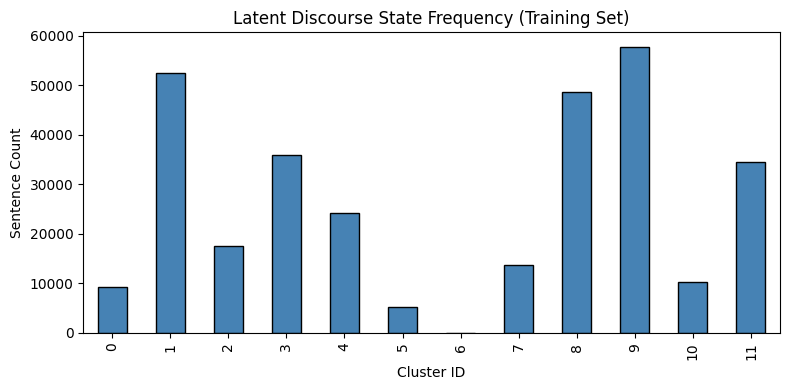

Saved cluster_frequency.png


In [27]:
# ── 8a. Cluster Distribution ───────────────────────────────────────────────
cluster_series = pd.Series(train_labels_flat, name='cluster')
print('Cluster value counts:')
print(cluster_series.value_counts().sort_index())

fig, ax = plt.subplots(figsize=(8, 4))
cluster_series.value_counts().sort_index().plot(kind='bar', ax=ax,
                                                color='steelblue', edgecolor='black')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Sentence Count')
ax.set_title('Latent Discourse State Frequency (Training Set)')
plt.tight_layout()
plt.savefig('cluster_frequency.png', dpi=150)
plt.show()
print('Saved cluster_frequency.png')

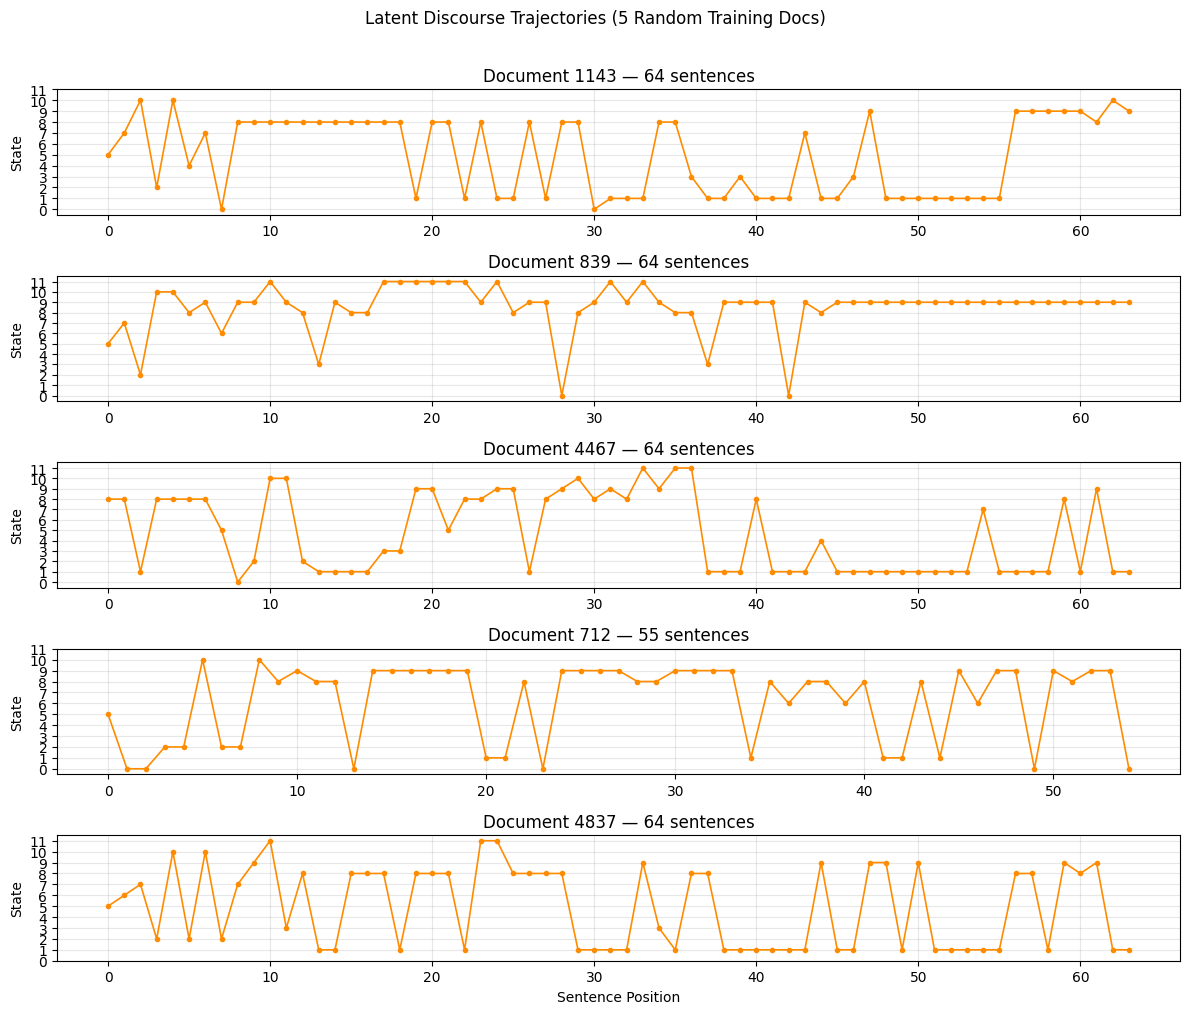

Saved discourse_trajectories.png


In [28]:
# ── 8b. Discourse Trajectory Visualisation (5 random documents) ────────────
def get_trajectory(doc_embs: np.ndarray) -> np.ndarray:
    """Assign each sentence embedding to a discourse state."""
    return kmeans.predict(doc_embs)

random_indices = random.sample(range(len(train_embs)), 5)

fig, axes = plt.subplots(5, 1, figsize=(12, 10))
for ax, idx in zip(axes, random_indices):
    traj = get_trajectory(train_embs[idx])
    ax.plot(range(len(traj)), traj, marker='o', markersize=3,
            linewidth=1.2, color='darkorange')
    ax.set_yticks(range(N_CLUSTERS))
    ax.set_ylabel('State')
    ax.set_title(f'Document {idx} — {len(traj)} sentences')
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Sentence Position')
plt.suptitle('Latent Discourse Trajectories (5 Random Training Docs)', y=1.01)
plt.tight_layout()
plt.savefig('discourse_trajectories.png', dpi=150)
plt.show()
print('Saved discourse_trajectories.png')

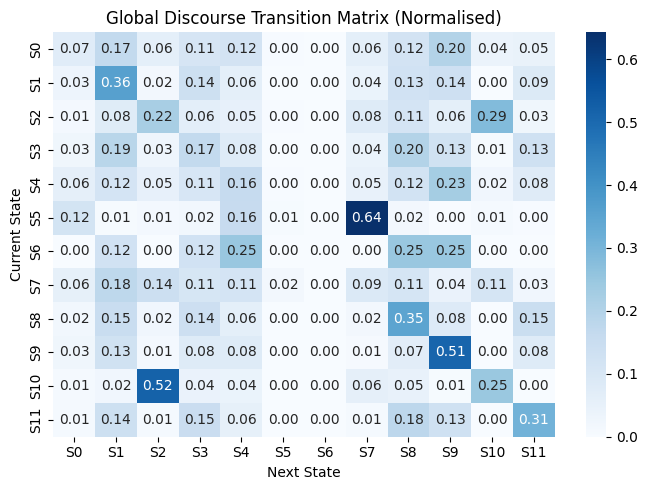

Saved transition_matrix.png


In [30]:
# ── 8c. Global Transition Matrix ──────────────────────────────────────────
transition_matrix = np.zeros((N_CLUSTERS, N_CLUSTERS), dtype=np.int64)

offset = 0
for embs in train_embs:
    n = len(embs)
    traj = train_labels_flat[offset:offset + n]
    offset += n
    for i in range(len(traj) - 1):
        transition_matrix[traj[i], traj[i + 1]] += 1

# Normalise to row probabilities
row_sums = transition_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
transition_probs = transition_matrix / row_sums

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(transition_probs, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'S{i}' for i in range(N_CLUSTERS)],
            yticklabels=[f'S{i}' for i in range(N_CLUSTERS)], ax=ax)
ax.set_xlabel('Next State')
ax.set_ylabel('Current State')
ax.set_title('Global Discourse Transition Matrix (Normalised)')
plt.tight_layout()
plt.savefig('transition_matrix.png', dpi=150)
plt.show()
print('Saved transition_matrix.png')

## Cell 9 — Dataset Construction

In [31]:
def build_trajectory_sequences(doc_embs_list: list,
                                max_len: int = MAX_LEN):
    """
    For each document:
      • Predict discourse state IDs  → (n_sent,)
      • Pad / truncate sentence embeddings to max_len
      • Pad / truncate state IDs     to max_len
      • Return actual length for masking

    Returns:
      emb_array   : (N_docs, max_len, 768)  float32
      state_array : (N_docs, max_len)       int64
      lengths     : (N_docs,)               int64
    """
    N = len(doc_embs_list)
    emb_array   = np.zeros((N, max_len, EMBED_DIM), dtype=np.float32)
    state_array = np.zeros((N, max_len), dtype=np.int64)
    lengths     = np.zeros(N, dtype=np.int64)

    for i, doc_embs in enumerate(doc_embs_list):
        states = kmeans.predict(doc_embs)          # (n_sent,)
        n      = min(len(doc_embs), max_len)
        emb_array[i, :n, :]  = doc_embs[:n]
        state_array[i, :n]   = states[:n]
        lengths[i]           = n

    return emb_array, state_array, lengths


print('Building trajectory sequences ...')
train_emb_arr, train_state_arr, train_lens = build_trajectory_sequences(train_embs)
dev_emb_arr,   dev_state_arr,   dev_lens   = build_trajectory_sequences(dev_embs)
test_emb_arr,  test_state_arr,  test_lens  = build_trajectory_sequences(test_embs)

print(f'train_emb_arr  : {train_emb_arr.shape}')
print(f'train_state_arr: {train_state_arr.shape}')
print('Sequences ready.')

Building trajectory sequences ...
train_emb_arr  : (5082, 64, 768)
train_state_arr: (5082, 64)
Sequences ready.


In [32]:
train_states = [
    kmeans.predict(doc)
    for doc in train_embs
]

dev_states = [
    kmeans.predict(doc)
    for doc in dev_embs
]

test_states = [
    kmeans.predict(doc)
    for doc in test_embs
]

In [33]:
print(train_states[0])
print(train_states[0].shape)

[8 8 8 9 9 9 9 1 8 1 8 1 1 7 1 1 1 9 1 8 9 9 9 9 1 1 9 9 1 9 9 9 9 9 9 8 9
 9 9 6 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 9 1 9 1 1 9 1 1]
(64,)


In [34]:
class DiscourseDataset(Dataset):
    """PyTorch Dataset for Discourse Trajectory sequences."""

    def __init__(self,
                 emb_arr: np.ndarray,
                 state_arr: np.ndarray,
                 lengths: np.ndarray,
                 labels):
        self.embs   = torch.from_numpy(emb_arr)    # (N, L, 768)
        self.states = torch.from_numpy(state_arr)  # (N, L)
        self.lens   = torch.from_numpy(lengths)    # (N,)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return (self.embs[idx],
                self.states[idx],
                self.lens[idx],
                self.labels[idx])


train_dataset = DiscourseDataset(train_emb_arr, train_state_arr,
                                 train_lens, train_df['label'].values)
dev_dataset   = DiscourseDataset(dev_emb_arr,   dev_state_arr,
                                 dev_lens,   dev_df['label'].values)
test_dataset  = DiscourseDataset(test_emb_arr,  test_state_arr,
                                 test_lens,  test_df['label'].values)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Dev   batches: {len(dev_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 318
Dev   batches: 157
Test  batches: 95


## Cell 10 — Model: DiscourseBiGRU

In [35]:
class AttentionPooling(nn.Module):
    """Soft attention over a sequence of hidden states."""

    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, hidden: torch.Tensor, lengths: torch.Tensor):
        """
        hidden  : (B, L, H)
        lengths : (B,)
        returns : (B, H)
        """
        scores = self.attn(hidden).squeeze(-1)           # (B, L)
        # Mask padding positions
        mask = torch.arange(hidden.size(1), device=hidden.device) \
                    .unsqueeze(0) >= lengths.unsqueeze(1)  # True = pad
        scores = scores.masked_fill(mask, float('-inf'))
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (B, L, 1)
        return (hidden * weights).sum(dim=1)             # (B, H)


class DiscourseBiGRU(nn.Module):
    """
    Architecture:
      Sentence Embedding (768) + State Embedding (64)  →  832-D
      BiGRU (hidden=256, bidir)  →  512-D per step
      Attention Pooling
      MLP: 512 → 256 → Dropout → 2
    """

    def __init__(self,
                 embed_dim:   int = EMBED_DIM,
                 n_states:    int = N_CLUSTERS,
                 state_dim:   int = STATE_DIM,
                 hidden_size: int = HIDDEN_SIZE,
                 dropout:     float = DROPOUT,
                 num_classes: int = 2,
                 mode:        str = 'full'):
        """
        mode options:
          'full'         — sentence emb + state emb  (Model C)
          'emb_only'     — sentence emb only          (Model A)
          'state_only'   — state emb only             (Model B)
        """
        super().__init__()
        self.mode = mode
        self.state_embedding = nn.Embedding(n_states, state_dim)

        if mode == 'full':
            input_dim = embed_dim + state_dim
        elif mode == 'emb_only':
            input_dim = embed_dim
        else:  # state_only
            input_dim = state_dim

        self.bigru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_size,
            bidirectional=True,
            batch_first=True
        )
        self.attn_pool = AttentionPooling(hidden_size * 2)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self,
                sent_embs: torch.Tensor,   # (B, L, 768)
                states:    torch.Tensor,   # (B, L)
                lengths:   torch.Tensor):  # (B,)
        state_embs = self.state_embedding(states)  # (B, L, 64)

        if self.mode == 'full':
            x = torch.cat([sent_embs, state_embs], dim=-1)  # (B, L, 832)
        elif self.mode == 'emb_only':
            x = sent_embs
        else:
            x = state_embs

        # Pack for efficiency
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        out_packed, _ = self.bigru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out_packed, batch_first=True)
        # out: (B, L, 512)

        pooled = self.attn_pool(out, lengths)  # (B, 512)
        logits = self.classifier(pooled)       # (B, 2)
        return logits


# Quick architecture test
dummy_model = DiscourseBiGRU().to(DEVICE)
B = 4
dummy_embs   = torch.randn(B, MAX_LEN, EMBED_DIM).to(DEVICE)
dummy_states = torch.randint(0, N_CLUSTERS, (B, MAX_LEN)).to(DEVICE)
dummy_lens   = torch.full((B,), MAX_LEN, dtype=torch.long).to(DEVICE)
out = dummy_model(dummy_embs, dummy_states, dummy_lens)
print(f'Test forward pass output shape: {out.shape}')  # expect (4, 2)
del dummy_model

Test forward pass output shape: torch.Size([4, 2])


## Cell 11 — Training & Evaluation Utilities

In [36]:
def compute_class_weights(labels) -> torch.Tensor:
    """Inverse-frequency class weights."""
    counts = np.bincount(labels)
    weights = 1.0 / counts
    weights = weights / weights.sum() * len(counts)
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    """Run model on loader and return all metrics."""
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for embs, states, lens, labels in loader:
            embs   = embs.to(DEVICE)
            states = states.to(DEVICE)
            lens   = lens.to(DEVICE)
            logits = model(embs, states, lens)
            probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            preds  = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels.numpy())

    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)

    return {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision':         precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':            recall_score(y_true, y_pred, average='macro', zero_division=0),
        'macro_f1':          f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'roc_auc':           roc_auc_score(y_true, y_prob),
        'clf_report':        classification_report(y_true, y_pred),
        'conf_matrix':       confusion_matrix(y_true, y_pred),
        'y_true': y_true,
        'y_pred': y_pred
    }


def print_metrics(metrics: dict, split: str = 'Validation'):
    print(f'\n=== {split} Metrics ===')
    print(f"  Accuracy          : {metrics['accuracy']:.4f}")
    print(f"  Balanced Accuracy : {metrics['balanced_accuracy']:.4f}")
    print(f"  Precision (macro) : {metrics['precision']:.4f}")
    print(f"  Recall (macro)    : {metrics['recall']:.4f}")
    print(f"  Macro F1          : {metrics['macro_f1']:.4f}")
    print(f"  Weighted F1       : {metrics['weighted_f1']:.4f}")
    print(f"  ROC-AUC           : {metrics['roc_auc']:.4f}")
    print(f"\nClassification Report:\n{metrics['clf_report']}")


def train_one_model(mode: str,
                    model_save_path: str,
                    num_epochs: int = NUM_EPOCHS) -> dict:
    """
    Full training loop for a given mode ('full', 'emb_only', 'state_only').
    Returns history dict with loss/f1 curves.
    """
    model = DiscourseBiGRU(mode=mode).to(DEVICE)
    class_weights = compute_class_weights(train_df['label'].values)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    best_f1  = 0.0
    history  = {'train_loss': [], 'val_macro_f1': []}

    for epoch in range(1, num_epochs + 1):
        # ── Training ──────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for embs, states, lens, labels in train_loader:
            embs   = embs.to(DEVICE)
            states = states.to(DEVICE)
            lens   = lens.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            logits = model(embs, states, lens)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), MAX_NORM)
            optimizer.step()
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)

        # ── Validation ────────────────────────────────────────────────────
        val_metrics = evaluate(model, dev_loader)
        val_f1 = val_metrics['macro_f1']
        scheduler.step(val_f1)

        history['train_loss'].append(avg_loss)
        history['val_macro_f1'].append(val_f1)

        print(f'  Epoch {epoch:02d}/{num_epochs}  '
              f'Loss={avg_loss:.4f}  Val Macro-F1={val_f1:.4f}'
              f'{'  ← best' if val_f1 > best_f1 else ""}')

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save({
                'epoch':              epoch,
                'model_state_dict':   model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_f1':            best_f1
            }, model_save_path)

    # Reload best checkpoint
    ckpt = torch.load(model_save_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    history['best_val_f1'] = best_f1
    history['model'] = model
    return history


print('Utilities defined.')

Utilities defined.


## Cell 12 — Train Full Model (Model C: Sentence Emb + Discourse State)

In [37]:
print('=' * 60)
print('Training Model C: Sentence Embeddings + Discourse States')
print('=' * 60)

history_C = train_one_model(
    mode='full',
    model_save_path=BEST_MODEL_PATH
)

print(f'\nBest Validation Macro-F1: {history_C["best_val_f1"]:.4f}')

Training Model C: Sentence Embeddings + Discourse States
  Epoch 01/20  Loss=0.6923  Val Macro-F1=0.4329  ← best
  Epoch 02/20  Loss=0.6847  Val Macro-F1=0.5362  ← best
  Epoch 03/20  Loss=0.6771  Val Macro-F1=0.5152
  Epoch 04/20  Loss=0.6689  Val Macro-F1=0.5336
  Epoch 05/20  Loss=0.6586  Val Macro-F1=0.5617  ← best
  Epoch 06/20  Loss=0.6381  Val Macro-F1=0.5790  ← best
  Epoch 07/20  Loss=0.6116  Val Macro-F1=0.5756
  Epoch 08/20  Loss=0.5861  Val Macro-F1=0.5823  ← best
  Epoch 09/20  Loss=0.5584  Val Macro-F1=0.5679
  Epoch 10/20  Loss=0.5225  Val Macro-F1=0.5459
  Epoch 11/20  Loss=0.4706  Val Macro-F1=0.5498
  Epoch 12/20  Loss=0.4119  Val Macro-F1=0.5591
  Epoch 13/20  Loss=0.3040  Val Macro-F1=0.5550
  Epoch 14/20  Loss=0.2602  Val Macro-F1=0.5208
  Epoch 15/20  Loss=0.2079  Val Macro-F1=0.5327
  Epoch 16/20  Loss=0.1628  Val Macro-F1=0.5226
  Epoch 17/20  Loss=0.1069  Val Macro-F1=0.5359
  Epoch 18/20  Loss=0.0850  Val Macro-F1=0.5278
  Epoch 19/20  Loss=0.0617  Val Macro-F

## Cell 13 — Ablation: Model A (Sentence Embeddings Only)

In [38]:
print('=' * 60)
print('Training Model A: Sentence Embeddings Only')
print('=' * 60)

history_A = train_one_model(
    mode='emb_only',
    model_save_path='best_model_A.pt'
)
print(f'Best Val Macro-F1 (Model A): {history_A["best_val_f1"]:.4f}')

Training Model A: Sentence Embeddings Only
  Epoch 01/20  Loss=0.6947  Val Macro-F1=0.4818  ← best
  Epoch 02/20  Loss=0.6816  Val Macro-F1=0.5824  ← best
  Epoch 03/20  Loss=0.6759  Val Macro-F1=0.5826  ← best
  Epoch 04/20  Loss=0.6709  Val Macro-F1=0.5062
  Epoch 05/20  Loss=0.6474  Val Macro-F1=0.5062
  Epoch 06/20  Loss=0.6210  Val Macro-F1=0.5747
  Epoch 07/20  Loss=0.5895  Val Macro-F1=0.5667
  Epoch 08/20  Loss=0.5574  Val Macro-F1=0.5633
  Epoch 09/20  Loss=0.5293  Val Macro-F1=0.5281
  Epoch 10/20  Loss=0.5076  Val Macro-F1=0.5717
  Epoch 11/20  Loss=0.4826  Val Macro-F1=0.5748
  Epoch 12/20  Loss=0.4396  Val Macro-F1=0.5642
  Epoch 13/20  Loss=0.4205  Val Macro-F1=0.5589
  Epoch 14/20  Loss=0.3961  Val Macro-F1=0.5538
  Epoch 15/20  Loss=0.3764  Val Macro-F1=0.5511
  Epoch 16/20  Loss=0.3427  Val Macro-F1=0.5500
  Epoch 17/20  Loss=0.3277  Val Macro-F1=0.5539
  Epoch 18/20  Loss=0.3183  Val Macro-F1=0.5507
  Epoch 19/20  Loss=0.3000  Val Macro-F1=0.5533
  Epoch 20/20  Loss=0

## Cell 14 — Ablation: Model B (Discourse State Trajectory Only)

In [39]:
print('=' * 60)
print('Training Model B: Discourse State Trajectory Only')
print('=' * 60)

history_B = train_one_model(
    mode='state_only',
    model_save_path='best_model_B.pt'
)
print(f'Best Val Macro-F1 (Model B): {history_B["best_val_f1"]:.4f}')

Training Model B: Discourse State Trajectory Only
  Epoch 01/20  Loss=0.6916  Val Macro-F1=0.5319  ← best
  Epoch 02/20  Loss=0.6882  Val Macro-F1=0.5333  ← best
  Epoch 03/20  Loss=0.6852  Val Macro-F1=0.5312
  Epoch 04/20  Loss=0.6834  Val Macro-F1=0.4939
  Epoch 05/20  Loss=0.6836  Val Macro-F1=0.5476  ← best
  Epoch 06/20  Loss=0.6818  Val Macro-F1=0.5285
  Epoch 07/20  Loss=0.6809  Val Macro-F1=0.5169
  Epoch 08/20  Loss=0.6777  Val Macro-F1=0.4750
  Epoch 09/20  Loss=0.6779  Val Macro-F1=0.5236
  Epoch 10/20  Loss=0.6733  Val Macro-F1=0.4909
  Epoch 11/20  Loss=0.6721  Val Macro-F1=0.5064
  Epoch 12/20  Loss=0.6670  Val Macro-F1=0.4735
  Epoch 13/20  Loss=0.6640  Val Macro-F1=0.4726
  Epoch 14/20  Loss=0.6606  Val Macro-F1=0.4818
  Epoch 15/20  Loss=0.6587  Val Macro-F1=0.4737
  Epoch 16/20  Loss=0.6564  Val Macro-F1=0.4845
  Epoch 17/20  Loss=0.6519  Val Macro-F1=0.4544
  Epoch 18/20  Loss=0.6502  Val Macro-F1=0.4856
  Epoch 19/20  Loss=0.6481  Val Macro-F1=0.4889
  Epoch 20/20 

## Cell 15 — Full Evaluation on Dev & Test Sets

In [40]:
# Evaluate all three models on dev + test
for name, hist, save_path, mode in [
    ('Model A (Emb Only)',    history_A, 'best_model_A.pt', 'emb_only'),
    ('Model B (State Only)',  history_B, 'best_model_B.pt', 'state_only'),
    ('Model C (Full)',        history_C, BEST_MODEL_PATH,   'full'),
]:
    model = DiscourseBiGRU(mode=mode).to(DEVICE)
    ckpt = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])

    dev_metrics  = evaluate(model, dev_loader)
    test_metrics = evaluate(model, test_loader)

    print(f'\n{"="*60}')
    print(f'{name}')
    print(f'{"="*60}')
    print_metrics(dev_metrics,  split='Dev')
    print_metrics(test_metrics, split='Test')


Model A (Emb Only)

=== Dev Metrics ===
  Accuracy          : 0.5826
  Balanced Accuracy : 0.5826
  Precision (macro) : 0.5826
  Recall (macro)    : 0.5826
  Macro F1          : 0.5826
  Weighted F1       : 0.5826
  ROC-AUC           : 0.6148

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.58      0.58      1252
           1       0.58      0.59      0.59      1259

    accuracy                           0.58      2511
   macro avg       0.58      0.58      0.58      2511
weighted avg       0.58      0.58      0.58      2511


=== Test Metrics ===
  Accuracy          : 0.5768
  Balanced Accuracy : 0.5768
  Precision (macro) : 0.5768
  Recall (macro)    : 0.5768
  Macro F1          : 0.5768
  Weighted F1       : 0.5768
  ROC-AUC           : 0.6036

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.58      0.58       755
           1       0.58      0.58      0.58    

## Cell 16 — Ablation Comparison Table

In [41]:
rows = []
for name, hist, save_path, mode in [
    ('Model A: Emb Only',   history_A, 'best_model_A.pt', 'emb_only'),
    ('Model B: State Only', history_B, 'best_model_B.pt', 'state_only'),
    ('Model C: Full',       history_C, BEST_MODEL_PATH,   'full'),
]:
    model = DiscourseBiGRU(mode=mode).to(DEVICE)
    ckpt  = torch.load(save_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    tm = evaluate(model, test_loader)
    rows.append({
        'Model':            name,
        'Accuracy':         f"{tm['accuracy']:.4f}",
        'Bal. Accuracy':    f"{tm['balanced_accuracy']:.4f}",
        'Precision':        f"{tm['precision']:.4f}",
        'Recall':           f"{tm['recall']:.4f}",
        'Macro F1':         f"{tm['macro_f1']:.4f}",
        'Weighted F1':      f"{tm['weighted_f1']:.4f}",
        'ROC-AUC':          f"{tm['roc_auc']:.4f}",
    })

ablation_df = pd.DataFrame(rows)
print('\n=== ABLATION STUDY — TEST SET ===')
print(ablation_df.to_string(index=False))


=== ABLATION STUDY — TEST SET ===
              Model Accuracy Bal. Accuracy Precision Recall Macro F1 Weighted F1 ROC-AUC
  Model A: Emb Only   0.5768        0.5768    0.5768 0.5768   0.5768      0.5768  0.6036
Model B: State Only   0.5425        0.5426    0.5427 0.5426   0.5424      0.5424  0.5529
      Model C: Full   0.5742        0.5746    0.5769 0.5746   0.5711      0.5709  0.6018


## Cell 17 — Visualizations

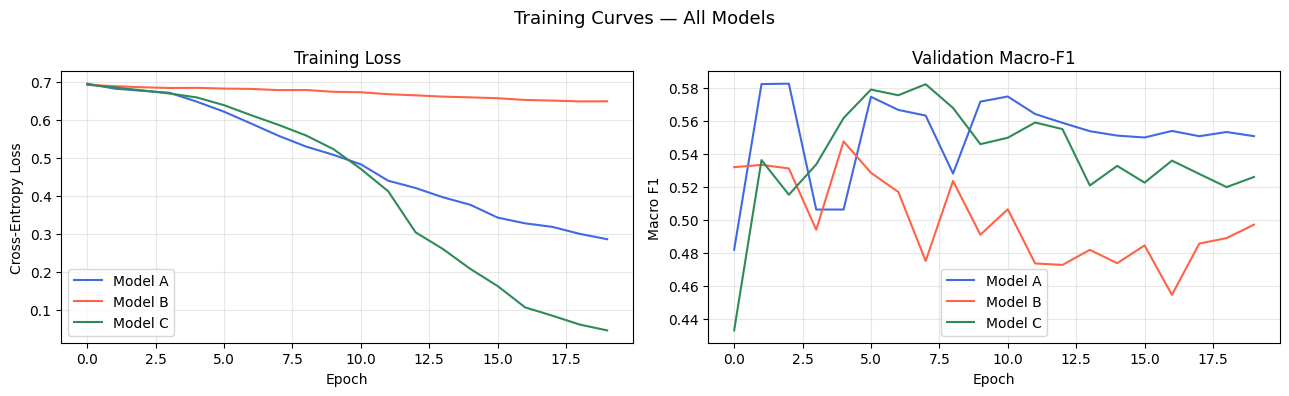

Saved training_curves.png


In [42]:
# ── Training Curves for Model C ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, hist, label, color in [
    (axes[0], history_A, 'Model A', 'royalblue'),
    (axes[0], history_B, 'Model B', 'tomato'),
    (axes[0], history_C, 'Model C', 'seagreen'),
]:
    ax.plot(hist['train_loss'], label=label, color=color)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for ax, hist, label, color in [
    (axes[1], history_A, 'Model A', 'royalblue'),
    (axes[1], history_B, 'Model B', 'tomato'),
    (axes[1], history_C, 'Model C', 'seagreen'),
]:
    ax.plot(hist['val_macro_f1'], label=label, color=color)

axes[1].set_title('Validation Macro-F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training Curves — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved training_curves.png')

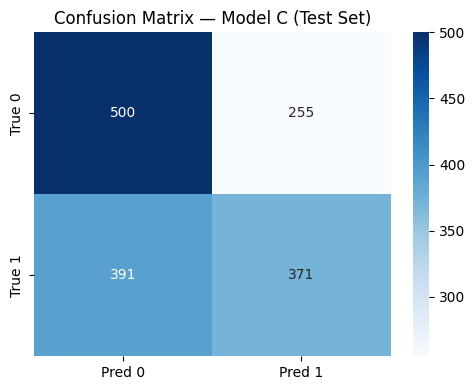

Saved confusion_matrix.png


In [43]:
# ── Confusion Matrix for Model C on Test Set ───────────────────────────────
best_model = DiscourseBiGRU(mode='full').to(DEVICE)
ckpt = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
best_model.load_state_dict(ckpt['model_state_dict'])
test_metrics = evaluate(best_model, test_loader)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(test_metrics['conf_matrix'],
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'],
            ax=ax)
ax.set_title('Confusion Matrix — Model C (Test Set)')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved confusion_matrix.png')

## Cell 18 — Save Final Model

In [44]:
torch.save({
    'model_name':        'DiscourseBiGRU',
    'num_states':        N_CLUSTERS,
    'input_shape':       (MAX_LEN, COMBINED_DIM),
    'best_val_f1':       history_C['best_val_f1'],
    'model_state_dict':  best_model.state_dict()
}, FINAL_MODEL_PATH)

print(f'Final model saved → {FINAL_MODEL_PATH}')
print('\n=== Pipeline Complete ===')
print(f'  Best Val Macro-F1 : {history_C["best_val_f1"]:.4f}')
print(f'  Test Macro-F1     : {test_metrics["macro_f1"]:.4f}')
print(f'  Test ROC-AUC      : {test_metrics["roc_auc"]:.4f}')
print(f'  Test Accuracy     : {test_metrics["accuracy"]:.4f}')

Final model saved → discourse_bigru_final.pt

=== Pipeline Complete ===
  Best Val Macro-F1 : 0.5823
  Test Macro-F1     : 0.5711
  Test ROC-AUC      : 0.6018
  Test Accuracy     : 0.5742


In [61]:
class FusionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        embeddings,
        transitions,
        max_len=64
    ):

        self.df = dataframe
        self.embeddings = embeddings
        self.transitions = transitions
        self.max_len = max_len

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        emb = self.embeddings[idx]

        # -------------------------
        # Pad / truncate embeddings
        # -------------------------

        if emb.shape[0] > self.max_len:

            emb = emb[:self.max_len]

        elif emb.shape[0] < self.max_len:

            pad = np.zeros(
                (
                    self.max_len - emb.shape[0],
                    emb.shape[1]
                ),
                dtype=np.float32
            )

            emb = np.vstack(
                [emb, pad]
            )

        emb = torch.tensor(
            emb,
            dtype=torch.float32
        )

        trans = torch.tensor(
            self.transitions[idx],
            dtype=torch.float32
        )

        label = torch.tensor(
            int(
                self.df.iloc[idx]["label"]
            ),
            dtype=torch.long
        )

        return emb, trans, label

In [63]:
train_ds = FusionDataset(
    train_df,
    train_embs,
    train_transitions
)

dev_ds = FusionDataset(
    dev_df,
    dev_embs,
    dev_transitions
)

test_ds = FusionDataset(
    test_df,
    test_embs,
    test_transitions
)

In [67]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

dev_loader = DataLoader(
    dev_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

In [68]:
batch = next(iter(train_loader))

print(len(batch))

for i, x in enumerate(batch):
    print(i, x.shape)

3
0 torch.Size([16, 64, 768])
1 torch.Size([16, 12, 12])
2 torch.Size([16])


In [69]:
print(train_embs[0].shape)
print(train_embs[14].shape)

(64, 768)
(15, 768)


In [70]:
import numpy as np

NUM_STATES = 12

def build_transition_matrix(state_seq):

    mat = np.zeros(
        (NUM_STATES, NUM_STATES),
        dtype=np.float32
    )

    for i in range(len(state_seq)-1):

        s1 = state_seq[i]
        s2 = state_seq[i+1]

        mat[s1, s2] += 1

    row_sums = mat.sum(
        axis=1,
        keepdims=True
    )

    mat = mat / (
        row_sums + 1e-8
    )

    return mat


train_transitions = [
    build_transition_matrix(x)
    for x in train_states
]

dev_transitions = [
    build_transition_matrix(x)
    for x in dev_states
]

test_transitions = [
    build_transition_matrix(x)
    for x in test_states
]

In [71]:
print(
    train_transitions[0].shape
)

print(
    train_transitions[0]
)

(12, 12)
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.4        0.         0.         0.         0.
  0.         0.06666667 0.2        0.33333334 0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         1.         0.         0.        ]
 [0.         1.         0.         0.         0.         0.
  0.         0.         0.  

In [72]:
batch = next(iter(train_loader))

print(type(batch))
print(len(batch))

<class 'list'>
3


In [49]:
for i, item in enumerate(batch):
    print(i, item.shape)

0 torch.Size([16, 64, 768])
1 torch.Size([16, 64])
2 torch.Size([16])
3 torch.Size([16])


In [75]:
import torch
import torch.nn as nn


class TransitionFusionModel(nn.Module):

    def __init__(self):

        super().__init__()

        # ===================================
        # Semantic Branch
        # ===================================

        self.bigru = nn.GRU(
            input_size=768,
            hidden_size=256,
            batch_first=True,
            bidirectional=True
        )

        self.attn = nn.Linear(
            512,
            1
        )

        # ===================================
        # Transition CNN Branch
        # ===================================

        self.cnn = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1,1)
            )
        )

        # ===================================
        # Fusion
        # ===================================

        self.classifier = nn.Sequential(

            nn.Linear(
                512 + 64,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                2
            )
        )

    def forward(
        self,
        embeddings,
        transitions
    ):

        # ===============================
        # Semantic branch
        # ===============================

        out, _ = self.bigru(
            embeddings
        )

        scores = self.attn(
            out
        )

        weights = torch.softmax(
            scores,
            dim=1
        )

        semantic_feat = (
            out * weights
        ).sum(dim=1)

        # ===============================
        # Transition branch
        # ===============================

        transitions = transitions.unsqueeze(1)

        trans_feat = self.cnn(
            transitions
        )

        trans_feat = trans_feat.flatten(
            start_dim=1
        )

        # ===============================
        # Fusion
        # ===============================

        fused = torch.cat(
            [
                semantic_feat,
                trans_feat
            ],
            dim=1
        )

        return self.classifier(
            fused
        )

In [76]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = TransitionFusionModel().to(device)

embs, trans, labels = next(
    iter(train_loader)
)

embs = embs.to(device)
trans = trans.to(device)

out = model(
    embs,
    trans
)

print(out.shape)

torch.Size([16, 2])


In [77]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch.nn as nn
import torch

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = TransitionFusionModel().to(device)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

weights = torch.tensor(
    weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

EPOCHS = 20

In [78]:
from sklearn.metrics import f1_score
from tqdm import tqdm
import torch

best_f1 = 0.0

for epoch in range(EPOCHS):

    # ==========================
    # TRAIN
    # ==========================

    model.train()

    train_loss = 0.0

    for embeddings, transitions, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):

        embeddings = embeddings.to(device)
        transitions = transitions.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(
            embeddings,
            transitions
        )

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ==========================
    # VALIDATION
    # ==========================

    model.eval()

    preds = []
    truths = []

    val_loss = 0.0

    with torch.no_grad():

        for embeddings, transitions, labels in dev_loader:

            embeddings = embeddings.to(device)
            transitions = transitions.to(device)
            labels = labels.to(device)

            logits = model(
                embeddings,
                transitions
            )

            loss = criterion(
                logits,
                labels
            )

            val_loss += loss.item()

            pred = logits.argmax(1)

            preds.extend(
                pred.cpu().numpy()
            )

            truths.extend(
                labels.cpu().numpy()
            )

    val_loss /= len(dev_loader)

    val_f1 = f1_score(
        truths,
        preds,
        average="macro"
    )

    scheduler.step(val_f1)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss={train_loss:.4f} | "
        f"Val Loss={val_loss:.4f} | "
        f"Val F1={val_f1:.4f}"
    )

    if val_f1 > best_f1:

        best_f1 = val_f1

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_f1": best_f1
            },
            "best_transition_fusion.pt"
        )

        print(
            f"✓ Saved Best Model "
            f"(F1={best_f1:.4f})"
        )

print("\n" + "="*60)
print("BEST VALIDATION F1:", best_f1)
print("="*60)

Epoch 1/20: 100%|██████████| 318/318 [00:04<00:00, 72.02it/s]


Epoch 01 | Train Loss=0.6917 | Val Loss=0.7172 | Val F1=0.3327
✓ Saved Best Model (F1=0.3327)


Epoch 2/20: 100%|██████████| 318/318 [00:04<00:00, 73.73it/s]


Epoch 02 | Train Loss=0.6826 | Val Loss=0.7088 | Val F1=0.4069
✓ Saved Best Model (F1=0.4069)


Epoch 3/20: 100%|██████████| 318/318 [00:04<00:00, 75.27it/s]


...

Epoch 18 | Train Loss=0.4187 | Val Loss=1.7964 | Val F1=0.4148


Epoch 19/20: 100%|██████████| 318/318 [00:04<00:00, 78.15it/s]


Epoch 19 | Train Loss=0.4112 | Val Loss=1.8327 | Val F1=0.4217


Epoch 20/20: 100%|██████████| 318/318 [00:04<00:00, 76.97it/s]


Epoch 20 | Train Loss=0.4085 | Val Loss=1.8758 | Val F1=0.4241

BEST VALIDATION F1: 0.5142351287092192
